# **Gojek App Review Analysis with NLP**

Di era digital saat ini, aplikasi layanan on-demand seperti Gojek telah menjadi bagian penting dalam kehidupan masyarakat Indonesia. Sebagai aplikasi super, Gojek menawarkan berbagai layanan seperti transportasi online, pesan-antar makanan, pembayaran digital, dan masih banyak lagi. Seiring dengan tingginya jumlah pengguna, Gojek menerima ribuan ulasan (review) dari pengguna setiap harinya melalui platform seperti Google Play Store dan App Store.

Review pengguna tersebut merupakan sumber data yang kaya dan berharga karena berisi opini, kritik, serta saran dari pengguna terhadap berbagai fitur aplikasi. Namun, karena jumlahnya yang sangat besar dan tidak terstruktur, sulit untuk menganalisis review tersebut secara manual. Di sinilah teknologi Natural Language Processing (NLP) berperan penting.

Dengan menggunakan metode NLP, kita dapat melakukan analisis otomatis terhadap review pengguna untuk mengidentifikasi sentimen dan bagaimana pendapat pengguna saat menggunakan aplikasi. Analisis ini dapat membantu tim pengembang memahami kebutuhan dan ekspektasi pengguna secara lebih mendalam, sehingga dapat meningkatkan kualitas layanan dan pengalaman pengguna.

Oleh karena itu, penelitian ini bertujuan untuk melakukan analisis terhadap review aplikasi Gojek dengan menggunakan teknik Natural Language Processing, guna melihat bagaimana pandangan pengguna terhadap aplikasi ini. 

# **Install & Import Libraries**

In [ ]:
# library untuk scraping data dari google play
pip install google-play-scraper

In [ ]:
# library untuk stemming dan penghapusan stopwords dengan bahasa indonesia
pip install Sastrawi

In [1]:
#libraries yang diperlukan untuk melakukan analisis
import pandas as pd
import numpy as np
from google_play_scraper import Sort, reviews_all
from string import punctuation
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import seaborn as sns
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
from google.cloud import bigquery
from pandas.io import gbq
from google.oauth2 import service_account
import pandas_gbq

# **Scraping Data**

scraping data dilakukan hanya sekali saat pertama kali menjalankan program.

In [ ]:
result = reviews_all(
    'com.gojek.app',
    sleep_milliseconds=0,
    lang='id',
    country ='id',
    sort = Sort.NEWEST,
    count = 10000,
    filter_score_with=None
)

In [ ]:
df = pd.DataFrame(np.array(result), columns=['review'])
df = df.join(pd.DataFrame(df.pop('review').tolist()))

In [ ]:
df.to_csv('gojek_app_review.csv', index = False)

# **Dataset**

**import dataset**

In [2]:
df = pd.read_csv('gojek_app_review.csv')
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,88f632f5-710d-4380-995d-016be2c8ac06,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"maaf bnget, pengalaman saya setiap pake gojek ...",1,0,5.14.2,2025-04-09 20:20:22,"Hai Kak Alda, mohon maaf atas ketidaknyamanann...",2025-04-09 23:22:35,5.14.2
1,e4159552-efe0-45ad-aae8-5b4276fc54e3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantep,5,0,5.14.2,2025-04-09 20:19:52,NaN,NaN,5.14.2
2,1faacce2-2f84-46fd-97dc-e3b283ee40af,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,dari dulu emang keren.....,5,0,5.14.2,2025-04-09 20:19:28,NaN,NaN,5.14.2
3,cb7fce78-2416-4be6-96cb-a9f2d4953772,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap sekali👍,5,0,5.15.1,2025-04-09 20:08:11,NaN,NaN,5.15.1
4,092e8756-b866-4699-9d23-5f010b3e3b7f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantab gan,5,0,5.14.2,2025-04-09 20:03:43,NaN,NaN,5.14.2
...,...,...,...,...,...,...,...,...,...,...,...
269995,27882f08-75d8-46cf-8b42-b2f1ea2a84dd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Goooo......,5,0,NaN,2022-05-08 14:06:33,NaN,NaN,NaN
269996,c350151b-901c-45c7-a2a5-2059ec09ca9f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Driver sering cancel tanpa informasi, setidkan...",1,0,NaN,2022-05-08 14:05:04,"Hai Yozora, mohon maaf untuk kendalanya. Lapor...",2022-05-09 08:35:29,NaN
269997,5bdadb60-01f9-4164-b71f-6f67a04ea5d7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"APK GAJELAS BURUK PARAH, LOGIN SALAH AJA PAKE ...",1,0,NaN,2022-05-08 13:54:03,"Hai Muhammad Hasan Aulia, mohon maaf atas kend...",2022-05-09 08:37:20,NaN
269998,9027fb4d-631b-4426-86d0-948ed6cf3232,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Banyak masalah apk nya,1,0,NaN,2022-05-08 13:53:12,"Hai Gana Putra, mohon maaf untuk kendalanya, a...",2022-05-09 08:37:48,NaN


**Ambil Sampel Dataset**

Sampel diambil sejumlah 10.000 dari 270.000 sampel secara acak. Pengambilang sampel ini dilakukan untuk mempercepat proses komputasi.

In [3]:
df = df.sample(n=10000, random_state=42)
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
268349,706f3a50-ec55-4eae-ada2-f9a63cc59b20,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Oke gojek terimakasih,5,3,4.43.1,2022-05-13 16:35:11,NaN,NaN,4.43.1
194386,442a65a5-d165-4598-99b6-3d8996a604c0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,TIDAK BISA GABUNG PROMO,1,0,NaN,2022-11-08 22:49:28,"Hai, mohon maaf ya. Laporan yang kamu sampaika...",2022-11-09 08:03:56,NaN
49524,e8a2e1fc-2ad9-48b9-b898-72abd89beedd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sampah mahal banget skrh,1,1,4.55.2,2024-07-29 20:55:21,"Mohon maaf atas ketidaknyamanannya, Kak Ashrul...",2024-07-29 21:28:07,4.55.2
140628,9e033428-c7e6-470f-bbdc-e3cc9c530183,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Makin ke sini makin nggak banget aplikasinya👎🏻,1,0,4.67.2,2023-06-20 17:23:09,"Hai Amalia, mohon maaf ya. Apabila kamu mengal...",2023-06-21 09:35:33,4.67.2
17828,7f6a8342-fb32-426f-a014-8a8aa6ac8885,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Gila yah denda playlater gede banget 50 rb han...,1,0,NaN,2025-01-02 17:50:00,"Hai Kak Vishie, mohon maaf atas ketidaknyamana...",2025-01-02 23:38:36,NaN
...,...,...,...,...,...,...,...,...,...,...,...
24681,424e9c65-eba3-4013-b117-fae12fb602b8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Setiap mau pakai gopay later selalu muncul tdk...,5,2,5.1.2,2024-12-02 08:05:09,NaN,NaN,5.1.2
230834,4406f998-eab1-486a-bef1-95437c96364d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus,5,0,4.48.1,2022-08-03 13:13:34,NaN,NaN,4.48.1
122138,cc6a6a29-a2a3-4bb4-b713-d4d5313f73c6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya ok ni apl, tapi nyari alamat kadang...",1,1,4.69.3,2023-09-02 18:12:40,"Hai, mohon maaf atas ketidaknyamanannya. Kriti...",2023-09-02 18:26:24,4.69.3
237763,c11017d9-32d0-49b1-9f4d-d3e6f68c953d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ok,4,0,NaN,2022-07-21 07:47:33,NaN,NaN,NaN


# **Cleaning Data**

In [4]:
df.shape

(10000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 268349 to 212190
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  7874 non-null   object
 7   at                    10000 non-null  object
 8   replyContent          3060 non-null   object
 9   repliedAt             3060 non-null   object
 10  appVersion            7874 non-null   object
dtypes: int64(2), object(9)
memory usage: 937.5+ KB


In [7]:
df = df.drop(columns=['reviewId', 'userName', 'userImage', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion'])

In [9]:
df.isnull().sum()

content          0
score            0
thumbsUpCount    0
dtype: int64

In [10]:
df

,content,score,thumbsUpCount
268349,Oke gojek terimakasih,5,3
194386,TIDAK BISA GABUNG PROMO,1,0
49524,Sampah mahal banget skrh,1,1
140628,Makin ke sini makin nggak banget aplikasinya👎🏻,1,0
17828,Gila yah denda playlater gede banget 50 rb han...,1,0
...,...,...,...
24681,Setiap mau pakai gopay later selalu muncul tdk...,5,2
230834,Bagus,5,0
122138,"Sebenarnya ok ni apl, tapi nyari alamat kadang...",1,1
237763,Ok,4,0


# **Text Preprocessing**

**Langkah 1 : Cleaning Data**

cleaning dilakukan untuk mengubah teks menjadi huruf kecil, menghapus tanda baca, URL, dan karakter-karakter yang tidak diperlukan dalam proses analisis.

In [11]:
def preprocessing_teks(teks):
    teks = str(teks).lower()  # lowercase
    teks = re.sub(r"http\S+", "", teks)  # hapus URL
    teks = re.sub(r"@\w+|#", "", teks)  # hapus mention dan hashtag
    teks = re.sub(r"[^\w\s]", "", teks)  # hapus tanda baca
    teks = re.sub(r"\d+", "", teks)  # hapus angka
    teks = re.sub(r"\s+", " ", teks).strip()  # hapus spasi berlebih
    return teks

In [12]:
df['content_bersih'] = df['content'].apply(preprocessing_teks)
df[['content', 'content_bersih']].head(10)

,content,content_bersih
268349,Oke gojek terimakasih,oke gojek terimakasih
194386,TIDAK BISA GABUNG PROMO,tidak bisa gabung promo
49524,Sampah mahal banget skrh,sampah mahal banget skrh
140628,Makin ke sini makin nggak banget aplikasinya👎🏻,makin ke sini makin nggak banget aplikasinya
17828,Gila yah denda playlater gede banget 50 rb han...,gila yah denda playlater gede banget rb hanya ...
170249,Aplikadi bagus saya suka terima kasih Gojeg,aplikadi bagus saya suka terima kasih gojeg
41455,Solutip,solutip
252467,Pelayanan baik,pelayanan baik
219816,Mantap terus pertahankan dan kembangkan untuk ...,mantap terus pertahankan dan kembangkan untuk ...
39351,Apk GK jls ngk bisa login peripikasi wajah gag...,apk gk jls ngk bisa login peripikasi wajah gag...


**Langkah 2 : Normalisasi Kata Tidak Baku**

Normalisasi kata tidak baku dilakukan untuk mengubah kata-kata yang tidak baku atau yang disingkat menjadi sesuai dengan ejaan.

In [13]:
normalisasi_kata = {
    'gak': 'tidak',
    'ga': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'tdk': 'tidak',
    'enggak': 'tidak',
    'tak': 'tidak',
    'gk' : 'tidak',
    'gitu': 'seperti itu',
    'gini': 'seperti ini',
    'gtu': 'seperti itu',
    'gt': 'seperti itu',
    'aja': 'saja',
    'aj': 'saja',
    'udh': 'sudah',
    'udah': 'sudah',
    'dah': 'sudah',
    'blm': 'belum',
    'belom': 'belum',
    'bgt': 'banget',
    'bngt': 'banget',
    'bgd': 'banget',
    'bgtu': 'begitu',
    'sm': 'sama',
    'smua': 'semua',
    'semua': 'semua',
    'dgn': 'dengan',
    'dg': 'dengan',
    'ama': 'sama',
    'sama2': 'sama-sama',
    'makasih': 'terima kasih',
    'makasi': 'terima kasih',
    'makasihhh': 'terima kasih',
    'thx': 'terima kasih',
    'thanks': 'terima kasih',
    'thankyou': 'terima kasih',
    'pls': 'tolong',
    'tolongin': 'tolong',
    'plis': 'tolong',
    'tolonglah': 'tolong',
    'plz': 'tolong',
    'bsk': 'besok',
    'bsok': 'besok',
    'kmrn': 'kemarin',
    'kemaren': 'kemarin',
    'kmren': 'kemarin',
    'skrg': 'sekarang',
    'skrang': 'sekarang',
    'skrng': 'sekarang',
    'dr': 'dari',
    'drpd': 'daripada',
    'kalo': 'kalau',
    'kl': 'kalau',
    'klu': 'kalau',
    'kluarga': 'keluarga',
    'klg': 'keluarga',
    'gw': 'saya',
    'gue': 'saya',
    'gua': 'saya',
    'sy': 'saya',
    'aq': 'aku',
    'aku': 'saya',
    'loe': 'kamu',
    'lu': 'kamu',
    'lo': 'kamu',
    'elu': 'kamu',
    'u': 'kamu',
    'km': 'kamu',
    'kmu': 'kamu',
    'ntar': 'nanti',
    'trus': 'terus',
    'trs': 'terus',
    'tp': 'tapi',
    'tpi': 'tapi',
    'knp': 'kenapa',
    'krn': 'karena',
    'karna': 'karena',
    'jg': 'juga',
    'ajaib': 'ajaib',
    'bikin': 'membuat',
    'cuma': 'hanya',
    'cuman': 'hanya',
    'mlm': 'malam',
    'pagi2': 'pagi-pagi',
    'bangunin': 'membangunkan',
    'apk': 'aplikasi',
    'jls': 'jelas',
    'ngk': 'tidak',
    'rb' : 'ribu',
    'bsa': 'bisa',
    'ak': 'saya',
    'yg': 'yang',
    'yng': 'yang'
}


def normalisasi_teks(teks, kamus):
    kata = teks.split()
    hasil = [kamus.get(k, k) for k in kata]
    return ' '.join(hasil)

In [14]:
df['content_normalisasi'] = df['content_bersih'].apply(lambda x: normalisasi_teks(x, normalisasi_kata))
df[['content_bersih','content_normalisasi']].head(10)

,content_bersih,content_normalisasi
268349,oke gojek terimakasih,oke gojek terimakasih
194386,tidak bisa gabung promo,tidak bisa gabung promo
49524,sampah mahal banget skrh,sampah mahal banget skrh
140628,makin ke sini makin nggak banget aplikasinya,makin ke sini makin tidak banget aplikasinya
17828,gila yah denda playlater gede banget rb hanya ...,gila yah denda playlater gede banget ribu hany...
170249,aplikadi bagus saya suka terima kasih gojeg,aplikadi bagus saya suka terima kasih gojeg
41455,solutip,solutip
252467,pelayanan baik,pelayanan baik
219816,mantap terus pertahankan dan kembangkan untuk ...,mantap terus pertahankan dan kembangkan untuk ...
39351,apk gk jls ngk bisa login peripikasi wajah gag...,aplikasi tidak jelas tidak bisa login peripika...


**Langkah 3 : Stopword Removal**

Menghapus kata-kata umum yang sering muncul dalam teks dan tidak memberikan makna penting secara konteks. 

In [15]:
# Ambil stopword list
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

In [16]:
def remove_stopwords(teks):
    tokens = teks.split()  # tokenisasi manual
    tokens_bersih = [t for t in tokens if t not in stopwords]
    return ' '.join(tokens_bersih)

In [17]:
df['content_stopwords'] = df['content_normalisasi'].apply(remove_stopwords)
df[['content_normalisasi', 'content_stopwords']].head(10)

,content_normalisasi,content_stopwords
268349,oke gojek terimakasih,oke gojek terimakasih
194386,tidak bisa gabung promo,gabung promo
49524,sampah mahal banget skrh,sampah mahal banget skrh
140628,makin ke sini makin tidak banget aplikasinya,makin sini makin banget aplikasinya
17828,gila yah denda playlater gede banget ribu hany...,gila yah denda playlater gede banget ribu tela...
170249,aplikadi bagus saya suka terima kasih gojeg,aplikadi bagus suka terima kasih gojeg
41455,solutip,solutip
252467,pelayanan baik,pelayanan baik
219816,mantap terus pertahankan dan kembangkan untuk ...,mantap terus pertahankan kembangkan mempermuda...
39351,aplikasi tidak jelas tidak bisa login peripika...,aplikasi jelas login peripikasi wajah gagal terus


**Langkah 4 : Stemming**

Mengubah kata ke bentuk kata dasar dengan menghapus awalan dan akhiran kata.

In [18]:
# Buat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [19]:
# Function untuk stemming
def stemming_text(text):
    return stemmer.stem(text)

In [20]:

# Terapkan stemming ke kolom clean_text
df['content_stemmed'] = df['content_stopwords'].apply(stemming_text)
df[['content_stopwords', 'content_stemmed']]

,content_stopwords,content_stemmed
268349,oke gojek terimakasih,oke gojek terimakasih
194386,gabung promo,gabung promo
49524,sampah mahal banget skrh,sampah mahal banget skrh
140628,makin sini makin banget aplikasinya,makin sini makin banget aplikasi
17828,gila yah denda playlater gede banget ribu tela...,gila yah denda playlater gede banget ribu tela...
...,...,...
24681,mau pakai gopay later selalu muncul koneksi in...,mau pakai gopay later selalu muncul koneksi in...
230834,bagus,bagus
122138,sebenarnya ni apl nyari alamat kadang susah pe...,benar ni apl nyari alamat kadang susah sen mak...
237763,,


# **Text Exploration**

**Frekuensi Kata**

Melihat 20 kata yang paling banyak muncul setelah melakukan proses preprocessing.

In [21]:
def get_word_freq(df_column):
    from collections import Counter
    all_words = ' '.join(df_column).split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(), columns=['kata', 'frekuensi'])

In [22]:
frekuensi_kata = get_word_freq(df['content_stemmed'])
frekuensi_kata.head(10)

,kata,frekuensi
0,gojek,1527
1,aplikasi,1410
2,sangat,1177
3,driver,1114
4,nya,1051
5,bantu,947
6,bagus,763
7,mantap,660
8,banget,616
9,baik,589


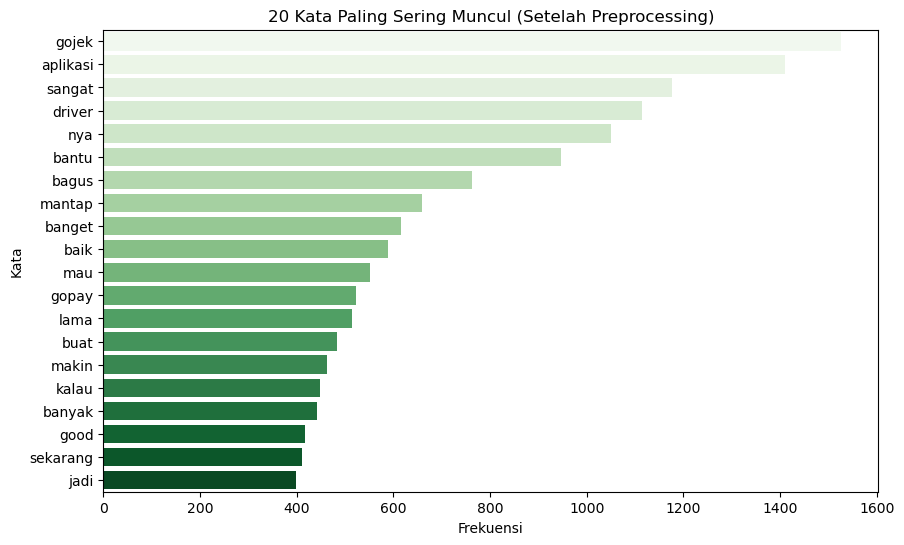

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x='frekuensi', y='kata', data=frekuensi_kata.head(20), palette='Greens')
plt.title('20 Kata Paling Sering Muncul (Setelah Preprocessing)')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

dari grafik frekuensi kata, terlihat bahwa kata "gojek", "aplikasi", dan "sangat" menjadi yang paling sering disebut dalam ulasan pengguna. Lalu, diikuti oleh kata-kata seperti "sangat", "bagus", dan "mantap" yang menunjukkan kecenderungan sentimen positif. Hal ini menunjukkan bahwa fokus ulasan pengguna tertuju pada layanan utama dan kualitas aplikasi, yang memberi gambaran bahwa pengalaman pengguna terhadap aspek-aspek tersebut sangat berpengaruh dalam pembentukan persepsi dan penilaian terhadap layanan.

**Distribusi Sentimen**

Melihat distribusi sentimen berdasarkan score yang dikelompokkan.

In [24]:
# word freq by scores
def get_sentiment(score):
    if score in [1, 2]:
        return 'negatif'
    elif score == 3:
        return 'netral'
    elif score in [4, 5]:
        return 'positif'

df['sentimen'] = df['score'].apply(get_sentiment)

In [25]:
df_positif = df[df['sentimen'] == 'positif']
df_netral = df[df['sentimen'] == 'netral']
df_negatif = df[df['sentimen'] == 'negatif']

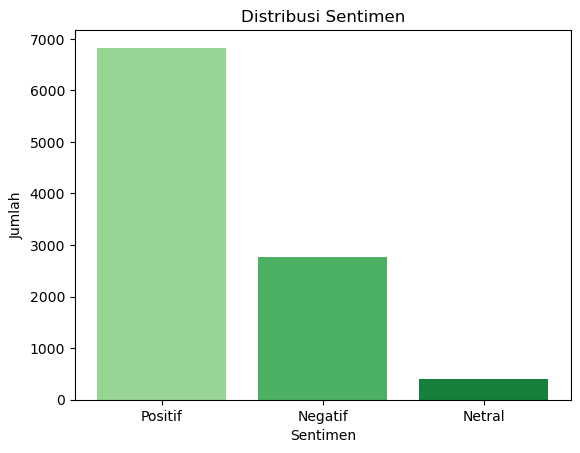

In [26]:
# menghitung banyak data per sentimen
sentimen_counts = [len(df_positif), len(df_negatif), len(df_netral)]
labels = ['Positif', 'Negatif', 'Netral']

# buat colormap hijau
cmap = plt.cm.Greens
colors = cmap(np.linspace(0.4, 0.8, len(sentimen_counts)))

# visualisasi
plt.bar(labels, sentimen_counts, color=colors)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

Dari grafik, terlihat bahwa mayoritas ulasan pengguna bersentimen positif, disusul oleh sentimen negatif, sementara sentimen netral hanya mencakup sebagian kecil dari total data. Hal ini menunjukkan bahwa pengguna memiliki pandangan yang baik terhadap layanan, namun tetap ada porsi signifikan dari pengguna yang menyampaikan keluhan atau pengalaman negatif. Rendahnya jumlah sentimen netral juga mengindikasikan bahwa mayoritas pengguna cenderung menyampaikan opini yang jelas, baik berupa pujian maupun kritik, daripada memberikan tanggapan yang bersifat netral atau ambigu.

**Frekuensi kata berdasarkan sentimen**

Top 10 Kata setiap Sentimen

In [27]:
def get_word_freq(text_series):
    all_words = ' '.join(text_series).split()
    return Counter(all_words)

# frekuensi kata per sentimen
freq_positif = get_word_freq(df_positif['content_stemmed'])
freq_netral = get_word_freq(df_netral['content_stemmed'])
freq_negatif = get_word_freq(df_negatif['content_stemmed'])

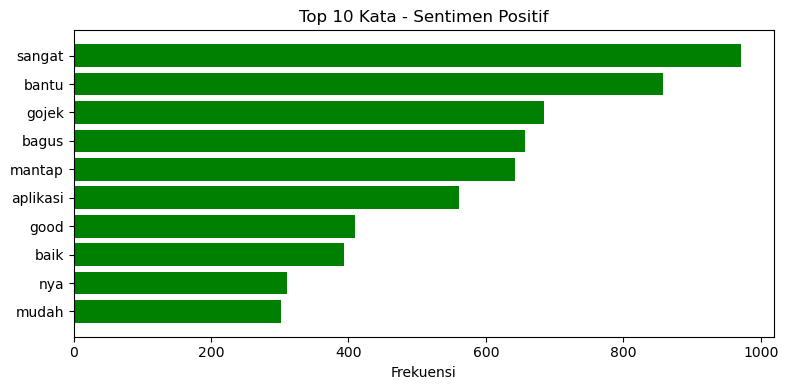

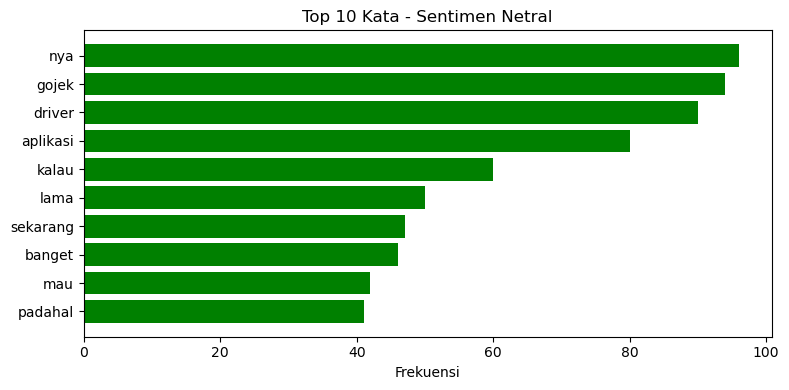

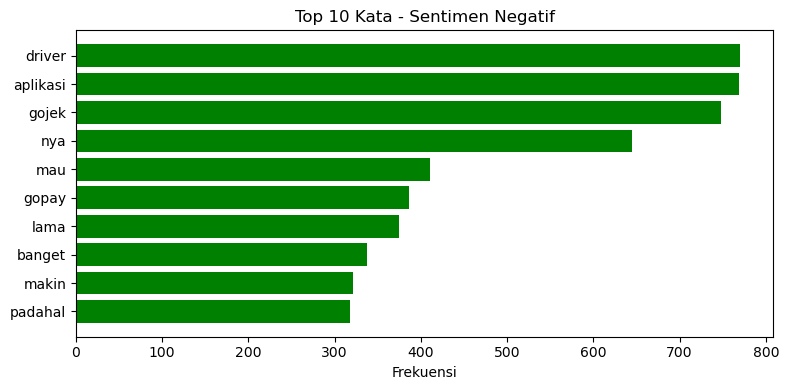

In [28]:
def plot_top_words(freq_dict, title, color):
    words, counts = zip(*freq_dict.most_common(10))
    plt.figure(figsize=(8, 4))
    plt.barh(words[::-1], counts[::-1], color=color)
    plt.xlabel("Frekuensi")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_words(freq_positif, 'Top 10 Kata - Sentimen Positif', 'green')
plot_top_words(freq_netral, 'Top 10 Kata - Sentimen Netral', 'green')
plot_top_words(freq_negatif, 'Top 10 Kata - Sentimen Negatif', 'green')

Berdasarkan ketiga grafik yang menampilkan sepuluh kata paling sering muncul pada masing-masing kategori sentimen, terlihat bahwa kata seperti "gojek", "aplikasi", dan "nya" muncul secara konsisten dalam semua sentimen. Ini menunjukkan bahwa kata-kata ini bersifat umum dan sering digunakan tanpa memandang konteks emosional. 
* Pada sentimen positif, kata-kata seperti " sangat", "bantu", "bagus", dan "mantap" mendominasi, mencerminkan pengalaman pengguna yang memuaskan dan pujian terhadap layanan. 
* Pada sentimen negatif, kata-kata seperti "driver", "gopay", dan "aplikasi" yang mengindikasikan adanya keluhan terhadap layanan atau fitur tertentu.
* Pasa sentimen netral, kata-kata yang menucul cenderung lebih bersifat informatif atau deskriptif seperti "driver", "kalau", "lama" yang menunjukkan bahwa pengguna mungkin hanya menyampaikan informasi tanpa ekspresi emosional yang kuat.

**Wordcloud**

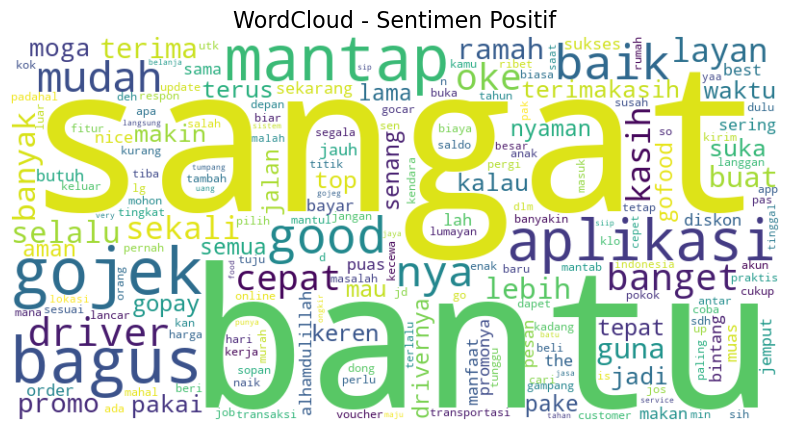

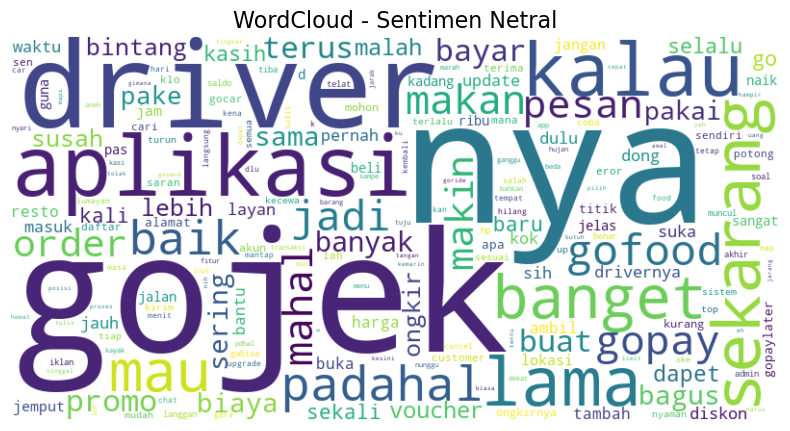

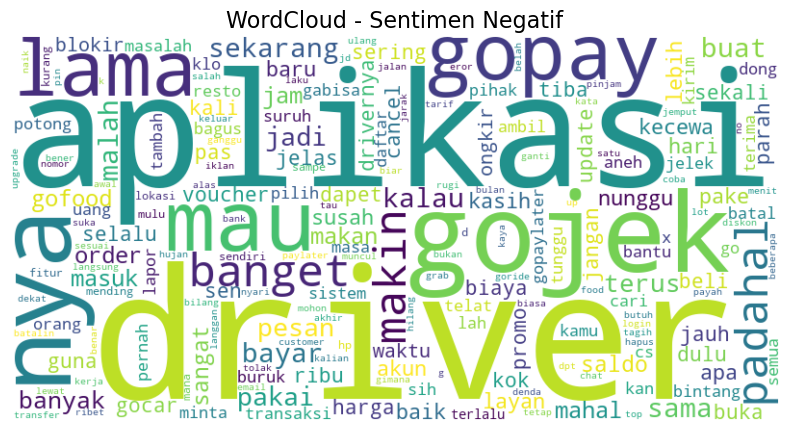

In [29]:
# fungsi wordcloud
def show_wordcloud(freq_dict, title):
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
    wc.generate_from_frequencies(freq_dict)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# tampilkan WordCloud
show_wordcloud(freq_positif, 'WordCloud - Sentimen Positif')
show_wordcloud(freq_netral, 'WordCloud - Sentimen Netral')
show_wordcloud(freq_negatif, 'WordCloud - Sentimen Negatif')


Berdasarkan ketiga wordcloud untuk masing-masing kategori sentimen, kata-kata seperti "gojek", "aplikasi", dan "driver" muncul secara dominan di semua jenis sentimen. Ini menunjukkan bahwa aspek layanan dan aplikasi gojek menjadi perhatian pengguna. 
* Pada sentimen positif, kata-kata seperti "sangat", "bantu", "bagus", dan "mantap" terlihat lebih besar dibandingkan dengan yang lainnya. Ini menunjukkan kepuasan pelanggan terhadap layanan yang diberikan oleh Gojek.
* Pada sentimen netral, kata-kata seperti "nya", "kalau", "lama", "sekarang", dan "padahal" yang cenderung bersifat deskriptif atau naratif tanpa emosi yang kuat.
* Pada sentimen negatif, kata-kata seperti "lama", "banget", "mau", dan "nunggu" yang menandakan keluhan terhadap layanan yang diberikan.

**Bobot Sentimen (Weighted Sentiment Score)**

Melihat bobot sentimen berdasarkan banyaknya thumbs up yang diberikan.

In [30]:
#menghitung bobot sentkmen
weighted_sentiment = df.groupby('sentimen')['thumbsUpCount'].sum().reset_index()
weighted_sentiment = weighted_sentiment.sort_values('thumbsUpCount', ascending=False)
weighted_sentiment

,sentimen,thumbsUpCount
0,negatif,4431
2,positif,1492
1,netral,466


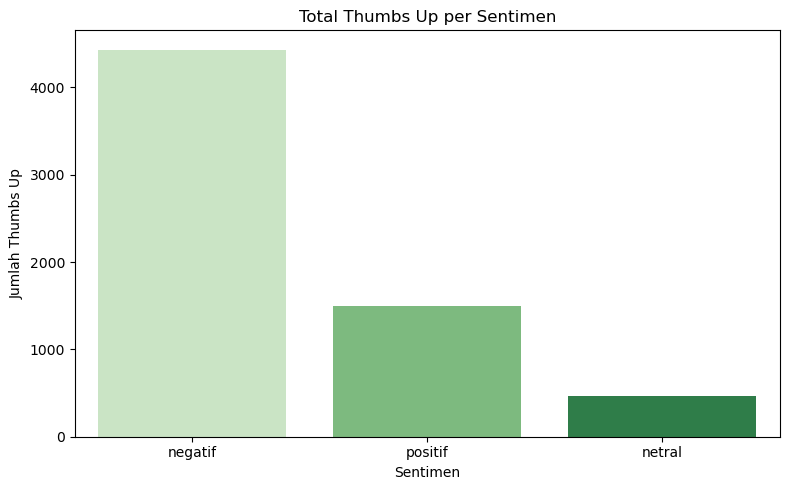

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(x='sentimen', y='thumbsUpCount', data=weighted_sentiment, palette='Greens')
plt.title('Total Thumbs Up per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Thumbs Up')
plt.tight_layout()
plt.show()

Grafik diatas menunjukkan bahwa total sentimen yang paling banyak diberikan thumbs up adalah sentimen negatif dibandingkan dengan sentimen positif dan netral. Hal ini menunjukkan bahwa komentar yang berisi keluhan atau kritik cenderung lebih mendapatkan perhatian atau persetujuan dari pengguna lain yang kemungkinan merasakan hal yang sama.

**Review Berkualitas (ThumbsUp > 0)**

Melihat seberapa berkualitas review setiap sentimen yang diberikan dengan melihat thumbs up yang diberikan.

In [32]:
# Tambahkan label review berkualitas
df['kategori_review'] = df['thumbsUpCount'].apply(lambda x: 'berkualitas' if x > 0 else 'biasa')

# Hitung jumlah review per kategori dan sentimen
review_summary = df.groupby(['sentimen', 'kategori_review']).size().reset_index(name='jumlah')
review_summary

,sentimen,kategori_review,jumlah
0,negatif,berkualitas,707
1,negatif,biasa,2063
2,netral,berkualitas,66
3,netral,biasa,337
4,positif,berkualitas,284
5,positif,biasa,6543


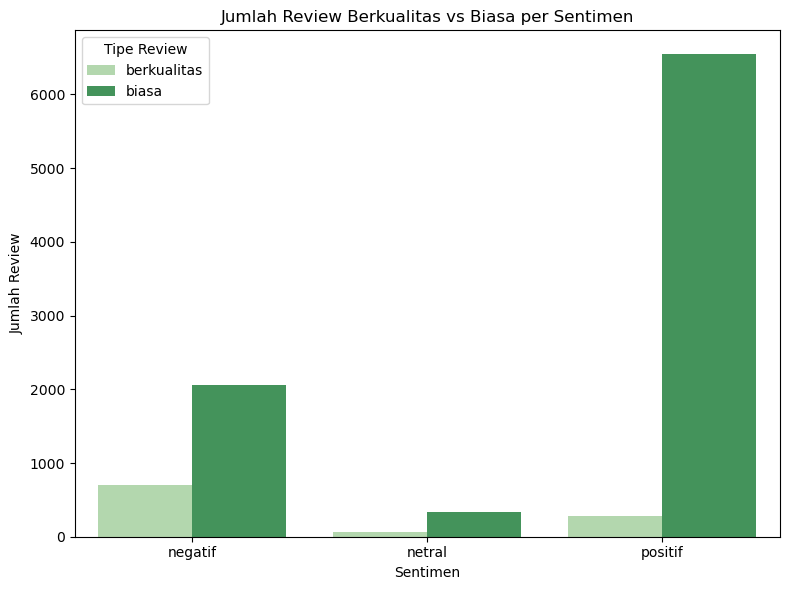

In [33]:
# ambil 2 warna hijau dari colormap "Greens"
warna_hijau = sns.color_palette('Greens', n_colors=2)

plt.figure(figsize=(8, 6))
sns.barplot(x='sentimen', y='jumlah', hue='kategori_review', data=review_summary, palette=warna_hijau)
plt.title('Jumlah Review Berkualitas vs Biasa per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')
plt.legend(title='Tipe Review')
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa review positif paling banyak jumlahnya, namum didominasi oleh review yang biasa saja. Sebaliknya, review negatif memiliki proporsi review berkualitas yang lebih tinggi. Ini menunjukkan bahwa pengguna lebih detail saat menyampaikan keluhan dibandingkan ketika memberikan pujian.

## **Kesimpulan**

Analisis terhadap ulasan pengguna menunjukkan bahwa layanan dan kualitas aplikasi menjadi fokus utama perhatian pengguna, sebagaimana tercermin dari frekuensi kata-kata seperti "gojek", "aplikasi", dan "driver" yang dominan di berbagai jenis sentimen. Mayoritas ulasan bersentimen positif, menandakan kepuasan pengguna secara umum, namun terdapat proporsi signifikan dari ulasan negatif yang berisi keluhan mendetail, terutama terkait fitur tertentu. Ulasan negatif justru cenderung lebih mendapatkan perhatian, terbukti dari jumlah thumbs up yang lebih tinggi dibandingkan ulasan positif. Selain itu, review negatif juga memiliki kualitas review yang lebih tinggi, sementara review positif lebih banyak yang bersifat biasa. Hal ini mengindikasikan bahwa pengguna cenderung lebih tergerak untuk menulis secara detail saat mengalami pengalaman yang kurang menyenangkan dibanding saat merasa puas.

## **Upload to BigQuery**

In [37]:
project_id = 'portofolio-module-2'
dataset_id = 'ehehe'
table_name = 'gojek_review_app'
key_path = r"D:\DATA\Data Science\modul 2\materi\ETL Big Query\hehehe\portofolio-module-2-dd678bdf2a5f.json"

scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

pandas_gbq.to_gbq(df, 
                  f'{dataset_id}.{table_name}',
                  project_id=project_id, 
                  if_exists='replace', 
                  credentials=credentials)

100%|██████████| 1/1 [00:00<?, ?it/s]
